# Exploratory Data Analysis for EEG features

EEG signals brain activity. The features in the below dataset are:

#### Brain wave bands:
δ_TP9: float64
θ_TP9: float64
α_TP9: float64
β_TP9: float64
γ_TP9: float64
δ_AF7: float64
θ_AF7: float64
α_AF7: float64
β_AF7: float64
γ_AF7: float64
δ_AF8: float64
θ_AF8: float64
α_AF8: float64
β_AF8: float64
γ_AF8: float64
δ_TP10: float64
θ_TP10: float64
α_TP10: float64
β_TP10: float64
γ_TP10: float64

#### Averaged and ratio features:

avg_δ: float64
avg_θ: float64
avg_α: float64
avg_β: float64
avg_γ: float64
rat_α/β: float64
rat_(θ + α)/β: float64
rat_(θ + α)/(α + β): float64
rat_θ/β: float64
rat_β/(θ + α): float64
rat_α/θ: float64
rat_θ/α: float64
avg_front_α_asy: float64

#### Wavelet features:

For each:
'AF7_a5', 'AF7_d3', 'AF7_d4', 'AF7_d5', 'AF8_a5',
'AF8_d3','AF8_d4', ‘AF8_d5’, 'TP9_a5',
'TP9_d3','TP9_d4', ‘TP9_d5’, 'TP10_a5', 'TP10_d3',
'TP10_d4', ‘TP10_d5'
We have: mean, median, variance, std dev, skew,
kurtosis, rms, energy => all floats

#### Averaged wavelet features:

Averaged Wavelet features
For each:
'avg_a5', 'avg_d3', 'avg_d4', 'avg_d5'
We have: mean, median, variance, std dev, skew,
kurtosis, rms, energy => all floats

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Keep a consistent class order
class_order = [
    "easy_arithmetic",
    "hard_arithmetic",
    "relaxation"
]

In [2]:
import pickle

In [3]:
def read_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f)
        return data

### Easy arithmetic

In [4]:
path = "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES140/Lab/Features/arithmetix_easy/EEG_features_30_sec.pickle"

In [5]:
EEG_30 = read_file(path)

In [6]:
EEG_30.head()

,δ_TP9,θ_TP9,α_TP9,β_TP9,γ_TP9,δ_AF7,θ_AF7,α_AF7,β_AF7,γ_AF7,...,avg_d4_rms,avg_d4_energy,avg_d3_mean,avg_d3_median,avg_d3_variance,avg_d3_std,avg_d3_skew,avg_d3_kurtosis,avg_d3_rms,avg_d3_energy
0,0.552949,0.249724,0.057866,0.063043,0.034789,0.603281,0.240076,0.043757,0.049212,0.033325,...,0.717095,249.913352,-0.009048,1.221245e-15,0.153267,0.391494,-10.295629,230.721803,0.391598,148.135325
1,0.623356,0.236296,0.051992,0.043922,0.018846,0.653154,0.219847,0.038868,0.037003,0.021338,...,1.164781,659.363350,-0.006885,0.000000e+00,0.448649,0.669813,-5.548788,139.032028,0.669848,433.440691
2,0.687987,0.199916,0.036652,0.038084,0.018984,0.688641,0.184139,0.038873,0.037471,0.024095,...,1.177647,674.009744,-0.004293,0.000000e+00,0.462678,0.680204,-5.327877,131.055507,0.680218,446.964661
3,0.673024,0.198891,0.035547,0.044362,0.029038,0.675535,0.179938,0.046455,0.041165,0.029334,...,1.179181,675.767041,-0.003086,2.220446e-16,0.470366,0.685833,-5.051688,127.760772,0.685840,454.383175
4,0.626905,0.239180,0.039662,0.045964,0.031364,0.609842,0.229846,0.057816,0.044080,0.033479,...,1.192121,690.680564,0.008238,4.662937e-15,0.490264,0.700188,-4.560163,118.606083,0.700237,473.660317


In [7]:
EEG_30.columns

Index(['δ_TP9', 'θ_TP9', 'α_TP9', 'β_TP9', 'γ_TP9', 'δ_AF7', 'θ_AF7', 'α_AF7',
       'β_AF7', 'γ_AF7',
       ...
       'avg_d4_rms', 'avg_d4_energy', 'avg_d3_mean', 'avg_d3_median',
       'avg_d3_variance', 'avg_d3_std', 'avg_d3_skew', 'avg_d3_kurtosis',
       'avg_d3_rms', 'avg_d3_energy'],
      dtype='object', length=193)

In [8]:
for column in EEG_30.columns:
    #print data type of column
    print(f"{column}: {EEG_30[column].dtype}")

δ_TP9: float64
θ_TP9: float64
α_TP9: float64
β_TP9: float64
γ_TP9: float64
δ_AF7: float64
θ_AF7: float64
α_AF7: float64
β_AF7: float64
γ_AF7: float64
δ_AF8: float64
θ_AF8: float64
α_AF8: float64
β_AF8: float64
γ_AF8: float64
δ_TP10: float64
θ_TP10: float64
α_TP10: float64
β_TP10: float64
γ_TP10: float64
avg_δ: float64
avg_θ: float64
avg_α: float64
avg_β: float64
avg_γ: float64
rat_α/β: float64
rat_(θ + α)/β: float64
rat_(θ + α)/(α + β): float64
rat_θ/β: float64
rat_β/(θ + α): float64
rat_α/θ: float64
rat_θ/α: float64
avg_front_α_asy: float64
TP9_a5_mean: float64
TP9_a5_median: float64
TP9_a5_variance: float64
TP9_a5_std: float64
TP9_a5_skew: float64
TP9_a5_kurtosis: float64
TP9_a5_rms: float64
TP9_a5_energy: float64
TP9_d5_mean: float64
TP9_d5_median: float64
TP9_d5_variance: float64
TP9_d5_std: float64
TP9_d5_skew: float64
TP9_d5_kurtosis: float64
TP9_d5_rms: float64
TP9_d5_energy: float64
TP9_d4_mean: float64
TP9_d4_median: float64
TP9_d4_variance: float64
TP9_d4_std: float64
TP9_d4_

In [9]:
EEG_30.describe()

,δ_TP9,θ_TP9,α_TP9,β_TP9,γ_TP9,δ_AF7,θ_AF7,α_AF7,β_AF7,γ_AF7,...,avg_d4_rms,avg_d4_energy,avg_d3_mean,avg_d3_median,avg_d3_variance,avg_d3_std,avg_d3_skew,avg_d3_kurtosis,avg_d3_rms,avg_d3_energy
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,0.673865,0.213138,0.034518,0.035811,0.018724,0.676677,0.205709,0.036926,0.034335,0.020928,...,0.537792,162.424217,-0.001303,6.319453e-16,0.150224,0.369037,-1.340091,128.960448,0.369155,145.197676
std,0.031538,0.023248,0.007097,0.006239,0.004113,0.031881,0.023738,0.005855,0.005830,0.004959,...,0.213213,137.790365,0.009144,2.304926e-15,0.099107,0.119093,4.560378,71.785272,0.119081,95.744579
min,0.552949,0.164860,0.024978,0.022896,0.012299,0.578162,0.151134,0.026626,0.022885,0.013635,...,0.162844,12.887807,-0.021414,-4.607426e-15,0.013669,0.116915,-14.614419,49.087930,0.116923,13.206112
25%,0.657441,0.196840,0.029605,0.031943,0.016039,0.653560,0.191548,0.032505,0.029966,0.017498,...,0.403342,79.065469,-0.008884,-4.440892e-16,0.087314,0.295487,-3.836363,83.510338,0.295699,84.466478
50%,0.676637,0.210818,0.032788,0.035500,0.017664,0.678863,0.202954,0.036912,0.033572,0.019912,...,0.523358,133.142329,-0.001239,6.418477e-16,0.131024,0.361951,-1.563925,109.799255,0.362156,126.713187
75%,0.696088,0.229362,0.037929,0.038730,0.020596,0.698665,0.221910,0.040161,0.037514,0.022817,...,0.622635,188.410192,0.004791,1.682682e-15,0.180080,0.424358,1.643544,138.962937,0.424386,173.980090
max,0.731385,0.273526,0.057866,0.063043,0.034789,0.735589,0.269504,0.058647,0.052542,0.039232,...,1.192121,690.680564,0.017946,8.715251e-15,0.490264,0.700188,9.098113,464.157220,0.700237,473.660317


In [10]:
EEG_30.shape

(96, 193)

In [11]:
EEG_30.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 193 entries, δ_TP9 to avg_d3_energy
dtypes: float64(193)
memory usage: 144.9 KB


In [12]:
EEG_30.isna().sum().sort_values(ascending=False)

δ_TP9              0
AF8_a5_mean        0
AF8_d3_variance    0
AF8_d3_std         0
AF8_d3_skew        0
                  ..
AF7_a5_variance    0
AF7_a5_std         0
AF7_a5_skew        0
AF7_a5_kurtosis    0
avg_d3_energy      0
Length: 193, dtype: int64

In [13]:
bands = ['δ','θ','α','β','γ']
ratio_features = [c for c in EEG_30.columns if 'rat_' in c]
wavelet_features = [c for c in EEG_30.columns if '_a' in c or '_d' in c]
avg_features = [c for c in EEG_30.columns if c.startswith('avg_')]

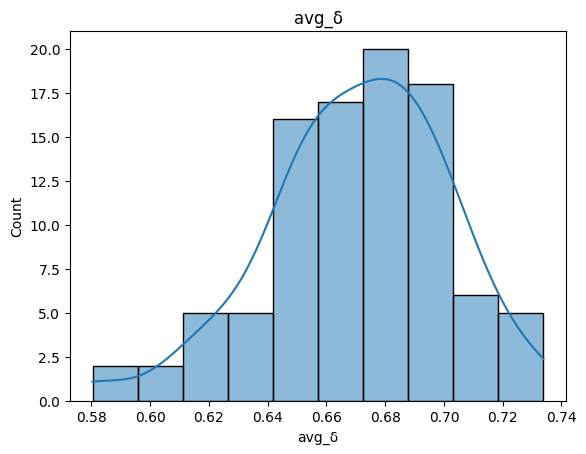

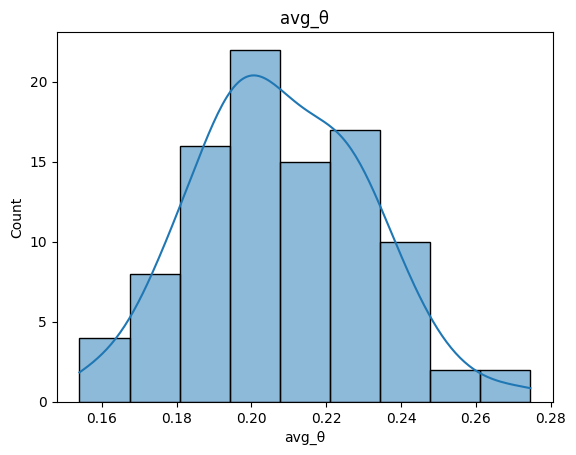

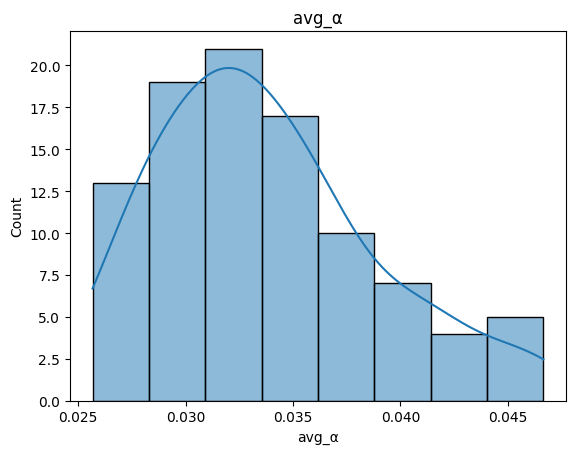

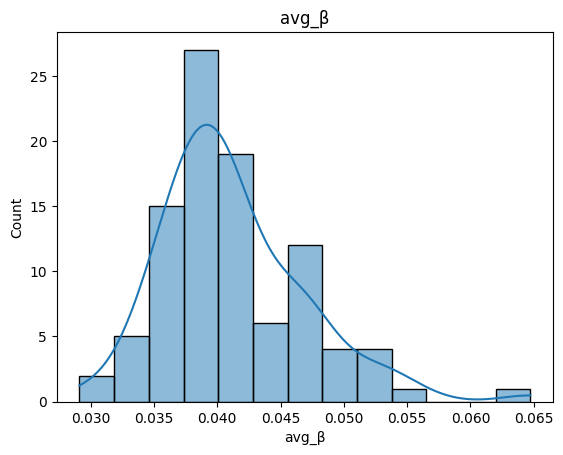

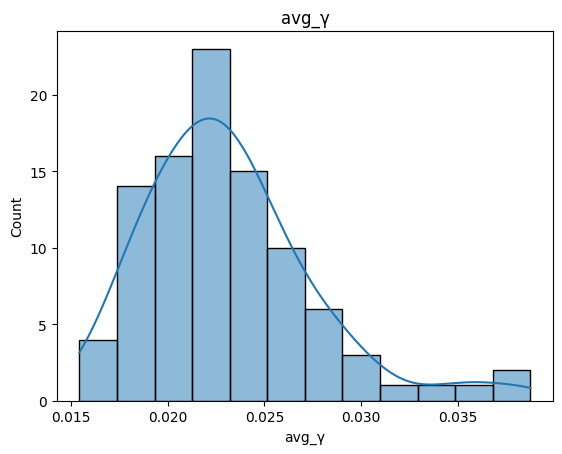

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

for band in ['avg_δ','avg_θ','avg_α','avg_β','avg_γ']:
    sns.histplot(EEG_30[band], kde=True)
    plt.title(band)
    plt.show()

<Axes: >

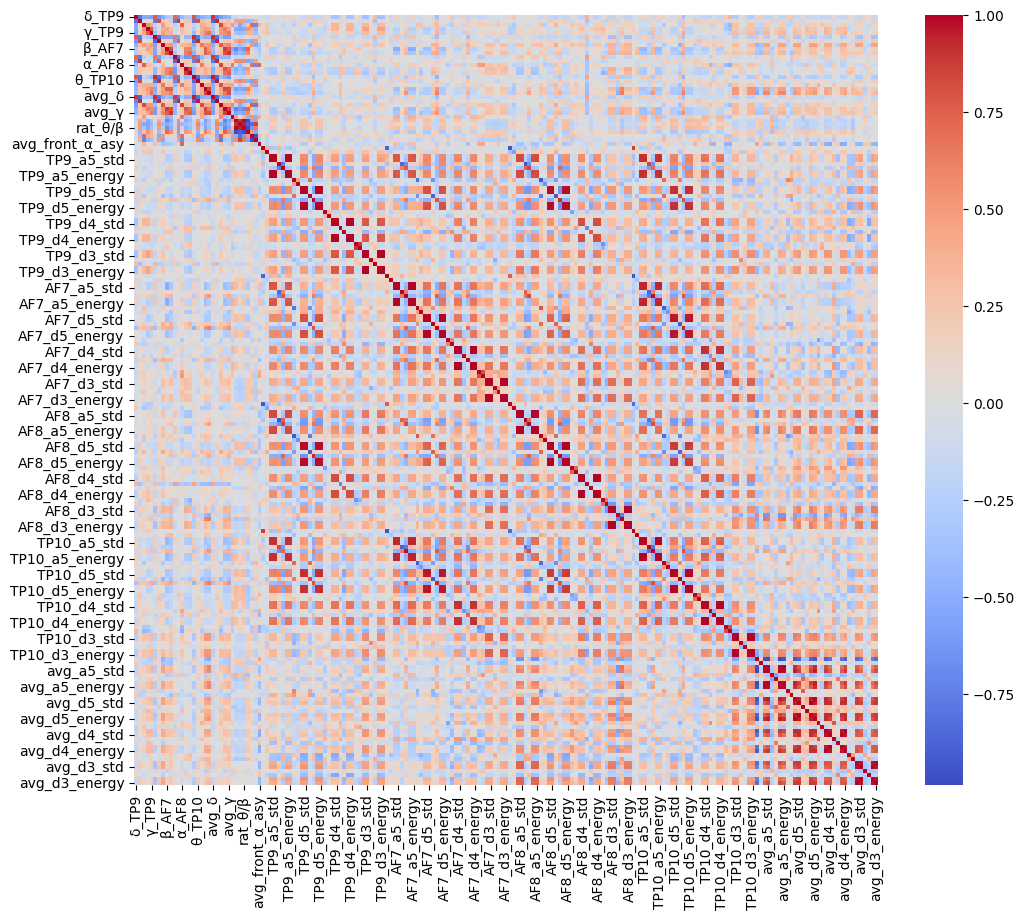

In [15]:
corr = EEG_30.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')

In [16]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(EEG_30)

,threshold,0.01


<Axes: >

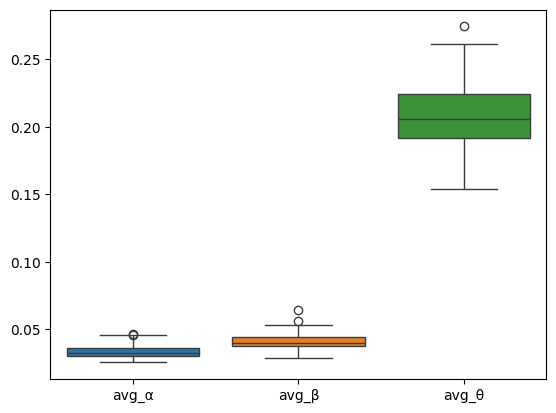

In [17]:
sns.boxplot(data=EEG_30[['avg_α','avg_β','avg_θ']])

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(EEG_30)

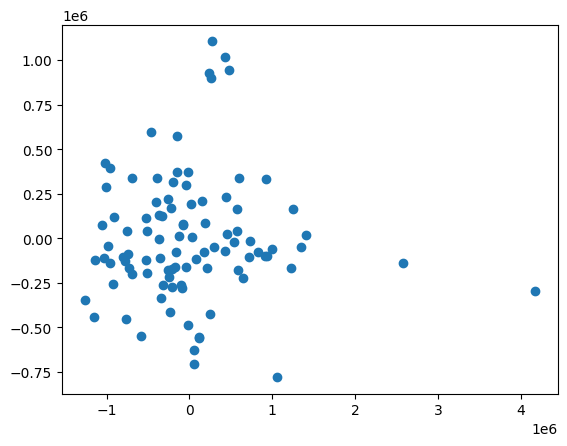

In [19]:
plt.scatter(X_pca[:,0], X_pca[:,1])

Scale b4 PCA

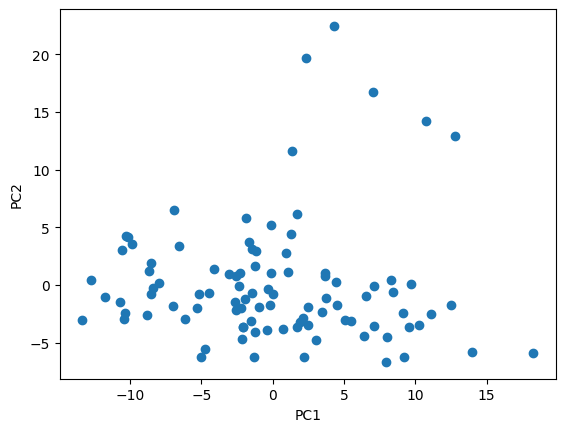

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = EEG_30.values

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

<Axes: >

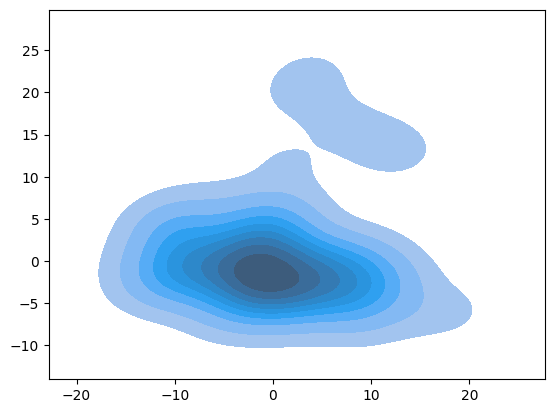

In [21]:
sns.kdeplot(x=X_pca[:,0], y=X_pca[:,1], fill=True)

In [22]:
pca.explained_variance_ratio_

array([0.23317027, 0.14210102])

### Merge dataset

In [23]:
import pandas as pd
import pickle
from pathlib import Path


task_paths = {
    "easy_arithmetic":
    "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES140/Lab/Features/arithmetix_easy/EEG_features_30_sec.pickle",

    "hard_arithmetic":
    "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES140/Lab/Features/arithmetix_hard/EEG_features_30_sec.pickle",

    "relaxation":
    "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES140/Lab/Features/relaxation_video/EEG_features_30_sec.pickle",

    
}

In [24]:
all_dfs = []

for task, path in task_paths.items():

    df = read_file(path)

    #label
    df["task_label"] = task

    all_dfs.append(df)


EEG_all = pd.concat(all_dfs, ignore_index=True)

print(EEG_all.shape)
EEG_all.head()

(288, 194)


,δ_TP9,θ_TP9,α_TP9,β_TP9,γ_TP9,δ_AF7,θ_AF7,α_AF7,β_AF7,γ_AF7,...,avg_d4_energy,avg_d3_mean,avg_d3_median,avg_d3_variance,avg_d3_std,avg_d3_skew,avg_d3_kurtosis,avg_d3_rms,avg_d3_energy,task_label
0,0.552949,0.249724,0.057866,0.063043,0.034789,0.603281,0.240076,0.043757,0.049212,0.033325,...,249.913352,-0.009048,1.221245e-15,0.153267,0.391494,-10.295629,230.721803,0.391598,148.135325,easy_arithmetic
1,0.623356,0.236296,0.051992,0.043922,0.018846,0.653154,0.219847,0.038868,0.037003,0.021338,...,659.363350,-0.006885,0.000000e+00,0.448649,0.669813,-5.548788,139.032028,0.669848,433.440691,easy_arithmetic
2,0.687987,0.199916,0.036652,0.038084,0.018984,0.688641,0.184139,0.038873,0.037471,0.024095,...,674.009744,-0.004293,0.000000e+00,0.462678,0.680204,-5.327877,131.055507,0.680218,446.964661,easy_arithmetic
3,0.673024,0.198891,0.035547,0.044362,0.029038,0.675535,0.179938,0.046455,0.041165,0.029334,...,675.767041,-0.003086,2.220446e-16,0.470366,0.685833,-5.051688,127.760772,0.685840,454.383175,easy_arithmetic
4,0.626905,0.239180,0.039662,0.045964,0.031364,0.609842,0.229846,0.057816,0.044080,0.033479,...,690.680564,0.008238,4.662937e-15,0.490264,0.700188,-4.560163,118.606083,0.700237,473.660317,easy_arithmetic


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
EEG_all["task_id"] = le.fit_transform(EEG_all["task_label"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'easy_arithmetic': 0, 'hard_arithmetic': 1, 'relaxation': 2}


In [26]:
X = EEG_all.drop(columns=["task_label", "task_id"])
y = EEG_all["task_id"]

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

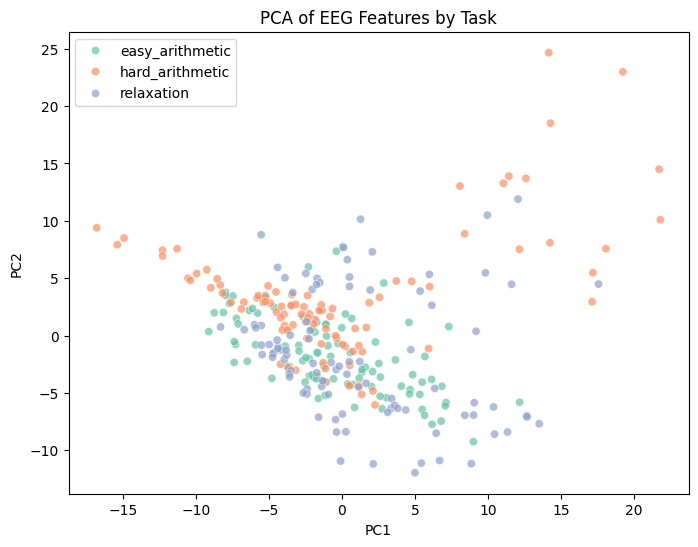

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=EEG_all["task_label"],
    palette="Set2",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of EEG Features by Task")
plt.legend()
plt.show()

In [30]:
EEG_all["task_label"].value_counts()

easy_arithmetic    96
hard_arithmetic    96
relaxation         96
Name: task_label, dtype: int64

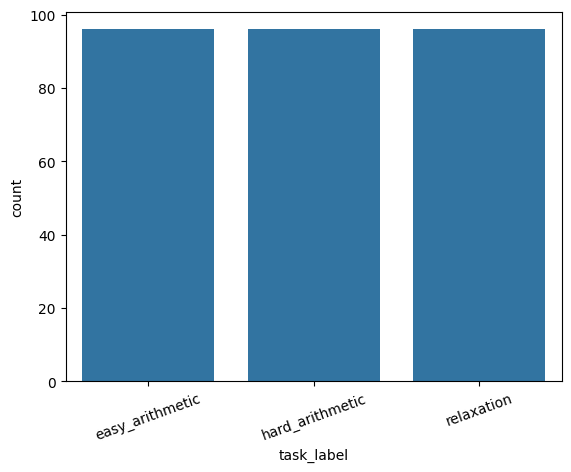

In [31]:
sns.countplot(data=EEG_all, x="task_label")
plt.xticks(rotation=20)
plt.show()

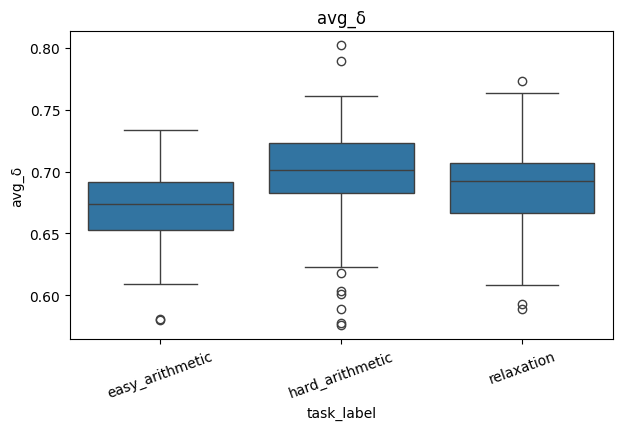

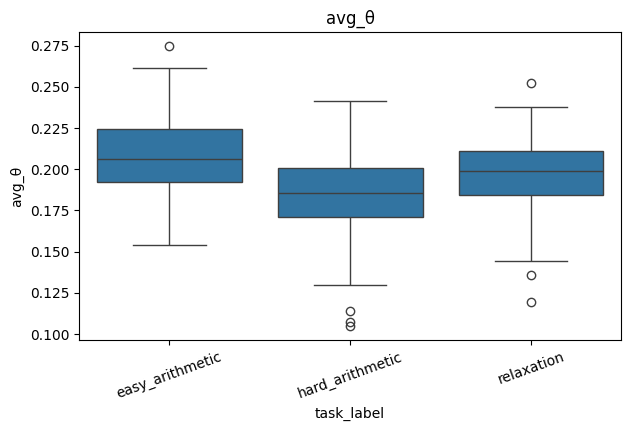

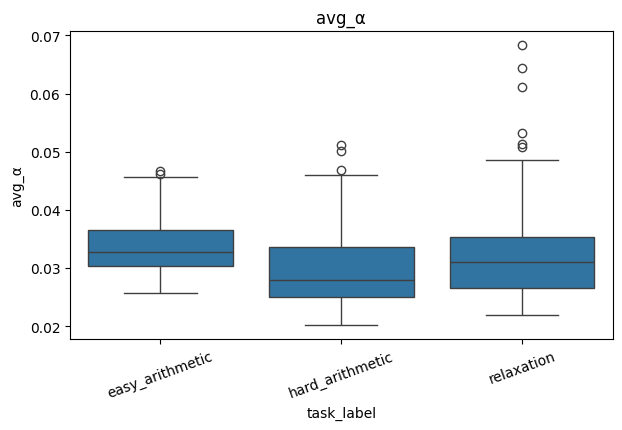

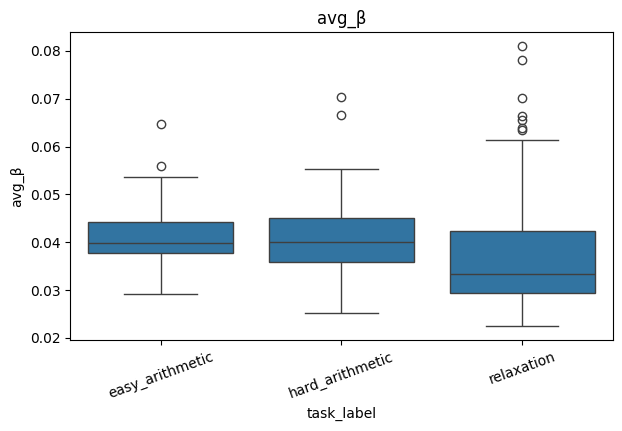

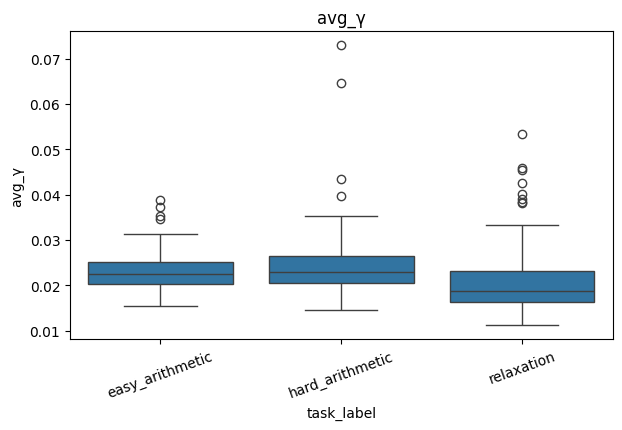

In [32]:
features = [
    "avg_δ",
    "avg_θ",
    "avg_α",
    "avg_β",
    "avg_γ"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=EEG_all,
        x="task_label",
        y=feature
    )
    plt.title(feature)
    plt.xticks(rotation=20)
    plt.show()

In [33]:
# Spectral band features at individual electrodes
band_features = [
    c for c in EEG_all.columns
    if any(c.startswith(f"{band}_") for band in ["δ", "θ", "α", "β", "γ"])
]

# Averaged spectral features
avg_band_features = [
    c for c in EEG_all.columns
    if c in ["avg_δ", "avg_θ", "avg_α", "avg_β", "avg_γ"]
]

# Ratio features
ratio_features = [
    c for c in EEG_all.columns
    if c.startswith("rat_")
]

# Asymmetry features
asymmetry_features = [
    c for c in EEG_all.columns
    if "asy" in c.lower()
]

# Wavelet features
wavelet_features = [
    c for c in EEG_all.columns
    if any(x in c for x in ["_a5", "_d3", "_d4", "_d5"])
]

print("Band features:", len(band_features))
print("Average band features:", len(avg_band_features))
print("Ratio features:", len(ratio_features))
print("Asymmetry features:", len(asymmetry_features))
print("Wavelet features:", len(wavelet_features))

Band features: 20
Average band features: 5
Ratio features: 7
Asymmetry features: 1
Wavelet features: 160


In [34]:
print("\nBand features:")
print(band_features)

print("\nAverage band features:")
print(avg_band_features)

print("\nRatio features:")
print(ratio_features)

print("\nAsymmetry features:")
print(asymmetry_features)


Band features:
['δ_TP9', 'θ_TP9', 'α_TP9', 'β_TP9', 'γ_TP9', 'δ_AF7', 'θ_AF7', 'α_AF7', 'β_AF7', 'γ_AF7', 'δ_AF8', 'θ_AF8', 'α_AF8', 'β_AF8', 'γ_AF8', 'δ_TP10', 'θ_TP10', 'α_TP10', 'β_TP10', 'γ_TP10']

Average band features:
['avg_δ', 'avg_θ', 'avg_α', 'avg_β', 'avg_γ']

Ratio features:
['rat_α/β', 'rat_(θ + α)/β', 'rat_(θ + α)/(α + β)', 'rat_θ/β', 'rat_β/(θ + α)', 'rat_α/θ', 'rat_θ/α']

Asymmetry features:
['avg_front_α_asy']


In [36]:
# for feature in avg_band_features:

#     plt.figure(figsize=(7, 5))

#     sns.boxplot(
#         data=EEG_all,
#         x="task_label",
#         y=feature,
#         order=class_order
#     )

#     sns.stripplot(
#         data=EEG_all,
#         x="task_label",
#         y=feature,
#         order=class_order,
#         alpha=0.15,
#         size=2
#     )

#     plt.title(f"{feature} by Task")
#     plt.xlabel("Task")
#     plt.ylabel(feature)
#     plt.xticks(rotation=20)
#     plt.tight_layout()
#     plt.show()

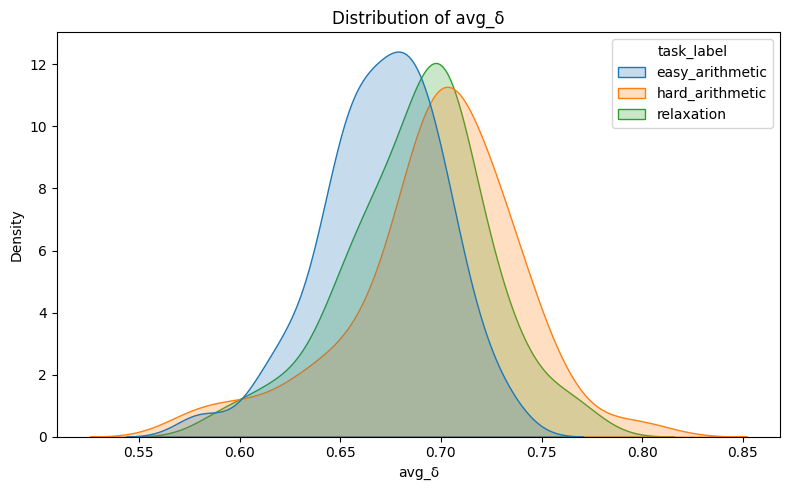

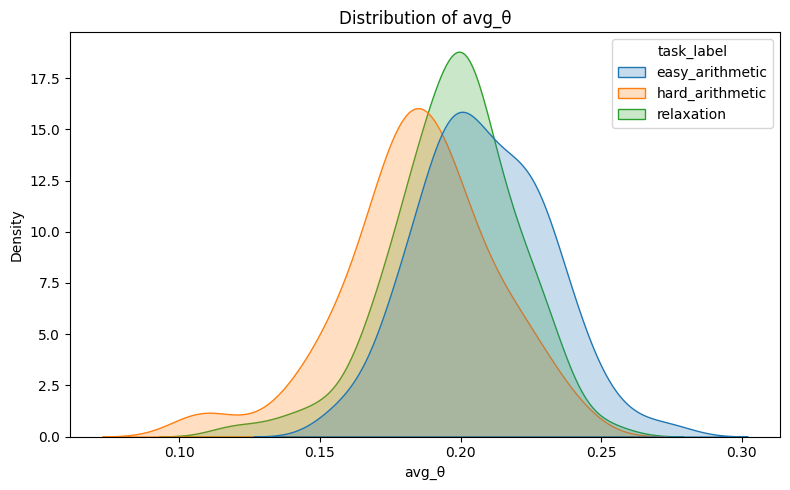

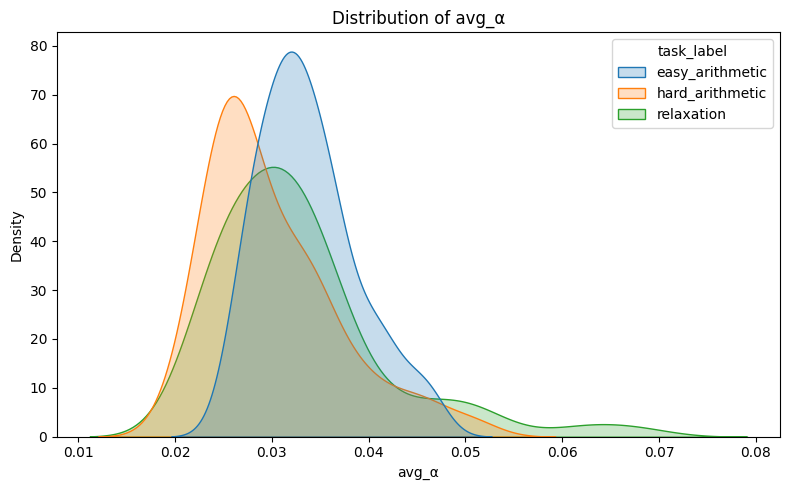

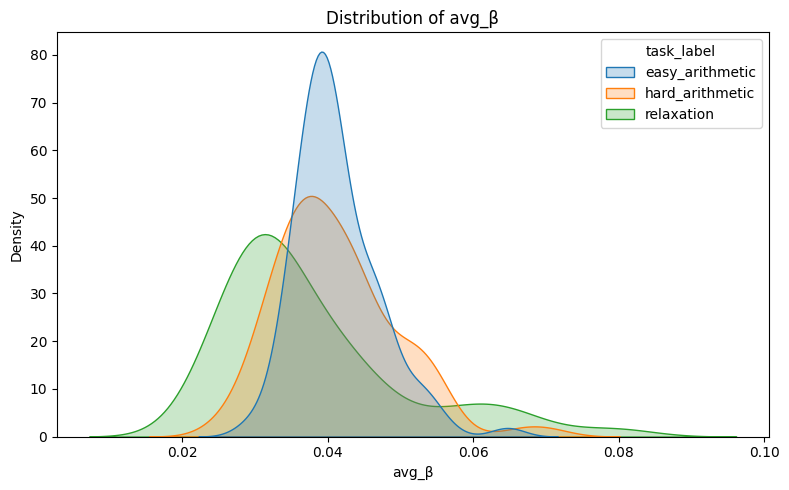

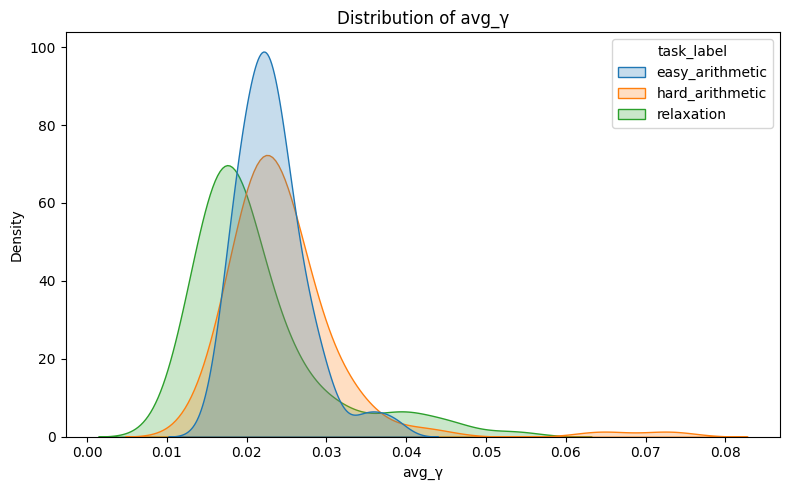

In [37]:
for feature in avg_band_features:

    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=EEG_all,
        x=feature,
        hue="task_label",
        hue_order=class_order,
        fill=True,
        common_norm=False,
        alpha=0.25
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

## Kruskal Wallis

In [38]:
from scipy.stats import kruskal

# Exclude labels
feature_columns = [
    c for c in EEG_all.columns
    if c not in ["task_label", "task_id"]
]

results = []

for feature in feature_columns:

    groups = [
        EEG_all.loc[
            EEG_all["task_label"] == task,
            feature
        ].dropna()
        for task in class_order
    ]

    # Skip features with insufficient data
    if any(len(group) < 2 for group in groups):
        continue

    try:
        statistic, p_value = kruskal(*groups)

        results.append({
            "feature": feature,
            "H_statistic": statistic,
            "p_value": p_value
        })

    except ValueError:
        continue

stats_results = pd.DataFrame(results)

stats_results = stats_results.sort_values("p_value")

stats_results.head(20)

,feature,H_statistic,p_value
123,AF8_d3_variance,98.403826,4.284308e-22
124,AF8_d3_std,98.403826,4.284308e-22
127,AF8_d3_rms,98.196009,4.753434e-22
128,AF8_d3_energy,98.196009,4.753434e-22
14,γ_AF8,73.074512,1.355412e-16
13,β_AF8,70.176564,5.772352e-16
96,AF7_d3_energy,62.186647,3.135748e-14
95,AF7_d3_rms,62.186647,3.135748e-14
92,AF7_d3_std,61.695613,4.008371e-14
91,AF7_d3_variance,61.695613,4.008371e-14


The H statistic measures how different the rank distributions are between groups.
H close to 0 → groups look very similar
Larger H → groups look increasingly different

Most of them have a reasonably high value which means all play a role in analysing group differences?

The p-value tells you whether those differences could have happened by chance.
Usually we use
p < 0.05 → significant
p < 0.01 → very significant
p < 0.001 → extremely significant

The p value is in 10^-13 which means they are very significant (I hope i havent made a mistake here)

Most discriminative features are:
AF8_d3
AF7_d3
AF7_d4
AF7_d5

Mental arithmetic is known to recruit frontal brain regions involved in executive function and working memory

## Benjamini-Hochberg FDR correction

In [78]:
from statsmodels.stats.multitest import multipletests

reject, pvals_corrected, _, _ = multipletests(
    stats_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

stats_results["p_fdr"] = pvals_corrected
stats_results["significant"] = reject

stats_results = stats_results.sort_values("p_fdr")

stats_results.head(30)

,feature,H_statistic,p_value,epsilon_squared,p_fdr,significant
0,AF8_d3_variance,98.403826,4.284308e-22,0.338259,2.293532e-20,True
1,AF8_d3_std,98.403826,4.284308e-22,0.338259,2.293532e-20,True
2,AF8_d3_rms,98.196009,4.753434e-22,0.337530,2.293532e-20,True
3,AF8_d3_energy,98.196009,4.753434e-22,0.337530,2.293532e-20,True
4,γ_AF8,73.074512,1.355412e-16,0.249384,5.231891e-15,True
5,β_AF8,70.176564,5.772352e-16,0.239216,1.856773e-14,True
6,AF7_d3_energy,62.186647,3.135748e-14,0.211181,7.564993e-13,True
7,AF7_d3_rms,62.186647,3.135748e-14,0.211181,7.564993e-13,True
9,AF7_d3_variance,61.695613,4.008371e-14,0.209458,7.736156e-13,True
8,AF7_d3_std,61.695613,4.008371e-14,0.209458,7.736156e-13,True


Even after correction the p values are very small (<<0.05 -> i set the threshold as 0.05) which means these features are very significant in differentiating between classes

In [41]:
print(
    f"Significant features after FDR correction: "
    f"{stats_results['significant'].sum()} / "
    f"{len(stats_results)}"
)

Significant features after FDR correction: 157 / 193


In [42]:
significant_features = stats_results.loc[
    stats_results["significant"],
    "feature"
].tolist()

print(significant_features)

['AF8_d3_variance', 'AF8_d3_std', 'AF8_d3_rms', 'AF8_d3_energy', 'γ_AF8', 'β_AF8', 'AF7_d3_energy', 'AF7_d3_rms', 'AF7_d3_variance', 'AF7_d3_std', 'AF7_d5_rms', 'AF7_d5_energy', 'AF7_d5_variance', 'AF7_d5_std', 'AF7_d4_rms', 'AF7_d4_energy', 'AF7_d4_std', 'AF7_d4_variance', 'TP9_d4_rms', 'rat_α/β', 'TP9_d4_energy', 'TP9_d4_variance', 'TP9_d4_std', 'avg_d5_mean', 'TP10_d5_std', 'TP10_d5_variance', 'TP10_d5_energy', 'TP10_d5_rms', 'avg_a5_mean', 'TP10_d3_median', 'avg_d5_skew', 'θ_AF8', 'α_AF7', 'TP9_d5_rms', 'TP9_d5_energy', 'δ_TP9', 'TP9_d5_std', 'TP9_d5_variance', 'TP10_d4_variance', 'TP10_d4_std', 'TP10_d4_energy', 'TP10_d4_rms', 'rat_β/(θ + α)', 'rat_(θ + α)/β', 'avg_θ', 'avg_d4_energy', 'avg_d4_rms', 'avg_d4_std', 'avg_d4_variance', 'θ_TP9', 'AF8_d3_median', 'avg_a5_rms', 'avg_a5_energy', 'avg_a5_std', 'avg_a5_variance', 'γ_TP9', 'rat_θ/β', 'avg_γ', 'θ_AF7', 'avg_δ', 'TP10_d3_mean', 'AF7_a5_median', 'δ_AF8', 'AF7_a5_energy', 'AF7_a5_rms', 'AF7_a5_variance', 'AF7_a5_std', 'AF8_d4_ku

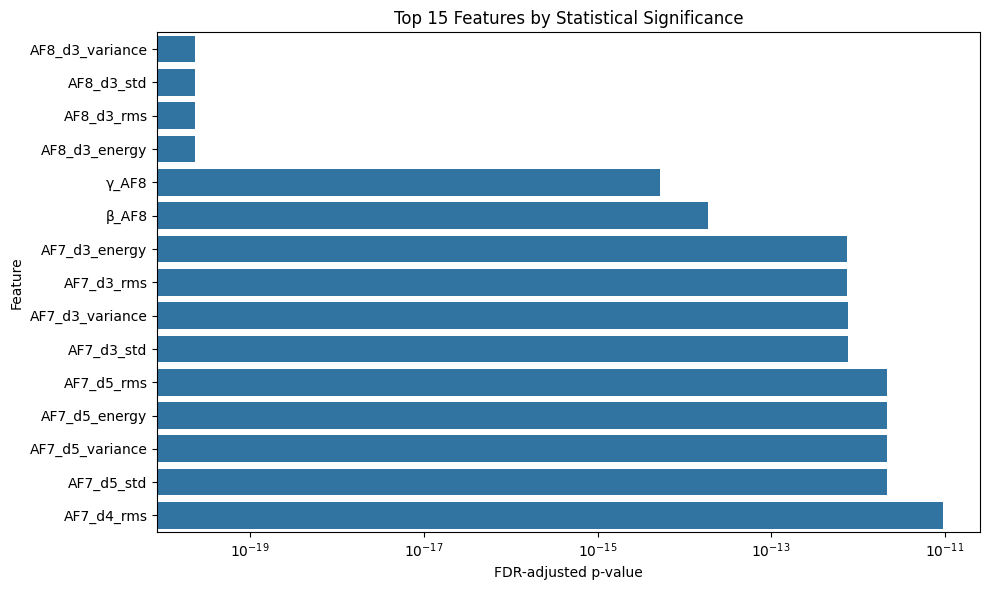

In [43]:
top_n = 15

top_features = stats_results.head(top_n)["feature"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=stats_results.head(top_n),
    x="p_fdr",
    y="feature"
)

plt.xscale("log")
plt.xlabel("FDR-adjusted p-value")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features by Statistical Significance")

plt.tight_layout()
plt.show()

### The lower the p value the more the significance

,feature,H_statistic,p_value
123,AF8_d3_variance,98.403826,4.284308e-22
124,AF8_d3_std,98.403826,4.284308e-22
127,AF8_d3_rms,98.196009,4.753434e-22
128,AF8_d3_energy,98.196009,4.753434e-22
14,γ_AF8,73.074512,1.355412e-16
13,β_AF8,70.176564,5.772352e-16
96,AF7_d3_energy,62.186647,3.135748e-14
95,AF7_d3_rms,62.186647,3.135748e-14
92,AF7_d3_std,61.695613,4.008371e-14
91,AF7_d3_variance,61.695613,4.008371e-14


## Effect sizes

$$\epsilon^2 = \frac{H - k + 1}{N - k}$$

where

H = Kruskal-Wallis statistic

k = number of groups

N = total observations

In [46]:
def epsilon_squared(H, n, k):
    """
    Effect size for Kruskal-Wallis test.
    """
    return (H - k + 1) / (n - k)

In [49]:
print(class_order)

['easy_arithmetic', 'hard_arithmetic', 'relaxation']


In [47]:
effect_results = []

k = len(class_order)

for _, row in stats_results.iterrows():

    feature = row["feature"]

    values = EEG_all[feature].dropna()

    n = len(values)

    if n <= k:
        continue

    effect = epsilon_squared(
        row["H_statistic"],
        n,
        k
    )

    effect_results.append({
        "feature": feature,
        "epsilon_squared": effect
    })

effect_results = pd.DataFrame(effect_results)

In [48]:
stats_results = stats_results.merge(
    effect_results,
    on="feature",
    how="left"
)

stats_results = stats_results.sort_values(
    "epsilon_squared",
    ascending=False
)

stats_results.head(30)

,feature,H_statistic,p_value,epsilon_squared
0,AF8_d3_variance,98.403826,4.284308e-22,0.338259
1,AF8_d3_std,98.403826,4.284308e-22,0.338259
2,AF8_d3_rms,98.196009,4.753434e-22,0.337530
3,AF8_d3_energy,98.196009,4.753434e-22,0.337530
4,γ_AF8,73.074512,1.355412e-16,0.249384
5,β_AF8,70.176564,5.772352e-16,0.239216
6,AF7_d3_energy,62.186647,3.135748e-14,0.211181
7,AF7_d3_rms,62.186647,3.135748e-14,0.211181
8,AF7_d3_std,61.695613,4.008371e-14,0.209458
9,AF7_d3_variance,61.695613,4.008371e-14,0.209458


this means that 34% of the variability in the ranked values of AF8_d3_variance is associated with the task class

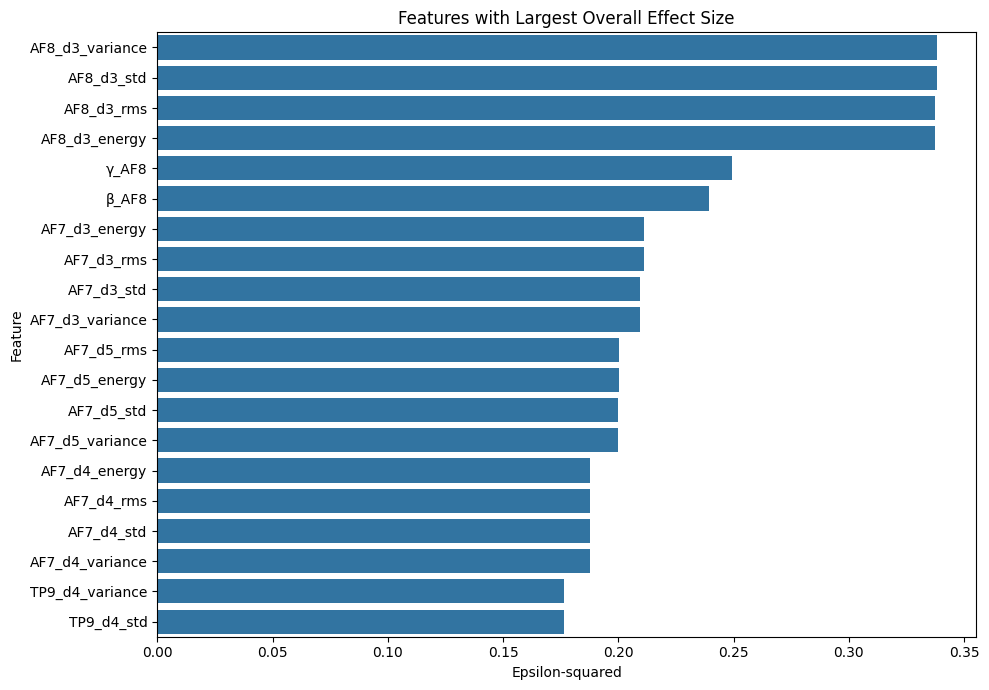

In [50]:
top_effect_features = stats_results.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_effect_features,
    x="epsilon_squared",
    y="feature"
)

plt.xlabel("Epsilon-squared")
plt.ylabel("Feature")
plt.title("Features with Largest Overall Effect Size")

plt.tight_layout()
plt.show()

## Pairwise class separability

In [52]:
from scipy.stats import mannwhitneyu

pairwise_comparisons = [
    ("easy_arithmetic", "hard_arithmetic"),
    ("easy_arithmetic", "relaxation"),
    ("hard_arithmetic", "relaxation")
]

In [53]:
pairwise_results = []

for feature in feature_columns:

    for class_a, class_b in pairwise_comparisons:

        x = EEG_all.loc[
            EEG_all["task_label"] == class_a,
            feature
        ].dropna()

        y = EEG_all.loc[
            EEG_all["task_label"] == class_b,
            feature
        ].dropna()

        if len(x) < 2 or len(y) < 2:
            continue

        try:
            statistic, p_value = mannwhitneyu(
                x,
                y,
                alternative="two-sided"
            )

            pairwise_results.append({
                "feature": feature,
                "class_a": class_a,
                "class_b": class_b,
                "U_statistic": statistic,
                "p_value": p_value
            })

        except ValueError:
            continue

pairwise_results = pd.DataFrame(pairwise_results)

In [54]:
reject, pvals_corrected, _, _ = multipletests(
    pairwise_results["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

pairwise_results["p_fdr"] = pvals_corrected
pairwise_results["significant"] = reject

pairwise_results = pairwise_results.sort_values("p_fdr")

pairwise_results.head(30)

,feature,class_a,class_b,U_statistic,p_value,p_fdr,significant
370,AF8_d3_variance,easy_arithmetic,relaxation,8013.0,9.327657e-19,1.516537e-16,True
373,AF8_d3_std,easy_arithmetic,relaxation,8013.0,9.327657e-19,1.516537e-16,True
382,AF8_d3_rms,easy_arithmetic,relaxation,8008.0,1.047694e-18,1.516537e-16,True
385,AF8_d3_energy,easy_arithmetic,relaxation,8008.0,1.047694e-18,1.516537e-16,True
371,AF8_d3_variance,hard_arithmetic,relaxation,7810.0,9.127964e-17,6.902102e-15,True
374,AF8_d3_std,hard_arithmetic,relaxation,7810.0,9.127964e-17,6.902102e-15,True
383,AF8_d3_rms,hard_arithmetic,relaxation,7808.0,9.536583e-17,6.902102e-15,True
386,AF8_d3_energy,hard_arithmetic,relaxation,7808.0,9.536583e-17,6.902102e-15,True
40,β_AF8,easy_arithmetic,relaxation,7609.0,6.516117e-15,4.192035e-13,True
43,γ_AF8,easy_arithmetic,relaxation,7498.0,6.132546e-14,3.550744e-12,True


most of them are between easy/hard arithmetic and relaxation which means there is a significant difference between tasks vs resting state. and for distinguishing between tasks AF7_d5_rms is useful because its p value is also quite small

In [55]:
def rank_biserial_from_u(U, n1, n2):
    """
    Rank-biserial correlation from Mann-Whitney U.
    """
    return (2 * U) / (n1 * n2) - 1

In [56]:
pairwise_effects = []

for _, row in pairwise_results.iterrows():

    feature = row["feature"]
    class_a = row["class_a"]
    class_b = row["class_b"]

    x = EEG_all.loc[
        EEG_all["task_label"] == class_a,
        feature
    ].dropna()

    y = EEG_all.loc[
        EEG_all["task_label"] == class_b,
        feature
    ].dropna()

    effect = rank_biserial_from_u(
        row["U_statistic"],
        len(x),
        len(y)
    )

    pairwise_effects.append(effect)

pairwise_results["rank_biserial"] = pairwise_effects

In [57]:
easy_hard = pairwise_results[
    (
        (pairwise_results["class_a"] == "easy_arithmetic") &
        (pairwise_results["class_b"] == "hard_arithmetic")
    )
]

easy_hard = easy_hard.sort_values("p_fdr")

easy_hard.head(20)

,feature,class_a,class_b,U_statistic,p_value,p_fdr,significant,rank_biserial
237,AF7_d5_rms,easy_arithmetic,hard_arithmetic,7129.0,5.879271e-11,1.098096e-09,True,0.547092
240,AF7_d5_energy,easy_arithmetic,hard_arithmetic,7129.0,5.879271e-11,1.098096e-09,True,0.547092
228,AF7_d5_std,easy_arithmetic,hard_arithmetic,7125.0,6.302327e-11,1.105772e-09,True,0.546224
225,AF7_d5_variance,easy_arithmetic,hard_arithmetic,7125.0,6.302327e-11,1.105772e-09,True,0.546224
429,TP10_d5_rms,easy_arithmetic,hard_arithmetic,7032.0,3.077440e-10,4.454595e-09,True,0.526042
432,TP10_d5_energy,easy_arithmetic,hard_arithmetic,7032.0,3.077440e-10,4.454595e-09,True,0.526042
420,TP10_d5_std,easy_arithmetic,hard_arithmetic,7028.0,3.290444e-10,4.536112e-09,True,0.525174
417,TP10_d5_variance,easy_arithmetic,hard_arithmetic,7028.0,3.290444e-10,4.536112e-09,True,0.525174
537,avg_d4_variance,easy_arithmetic,hard_arithmetic,2220.0,5.599073e-10,7.164923e-09,True,-0.518229
540,avg_d4_std,easy_arithmetic,hard_arithmetic,2220.0,5.599073e-10,7.164923e-09,True,-0.518229


In [58]:
easy_relax = pairwise_results[
    (
        (pairwise_results["class_a"] == "easy_arithmetic") &
        (pairwise_results["class_b"] == "relaxation")
    )
]

easy_relax = easy_relax.sort_values("p_fdr")

easy_relax.head(20)

,feature,class_a,class_b,U_statistic,p_value,p_fdr,significant,rank_biserial
370,AF8_d3_variance,easy_arithmetic,relaxation,8013.0,9.327657e-19,1.516537e-16,True,0.738932
373,AF8_d3_std,easy_arithmetic,relaxation,8013.0,9.327657e-19,1.516537e-16,True,0.738932
382,AF8_d3_rms,easy_arithmetic,relaxation,8008.0,1.047694e-18,1.516537e-16,True,0.737847
385,AF8_d3_energy,easy_arithmetic,relaxation,8008.0,1.047694e-18,1.516537e-16,True,0.737847
40,β_AF8,easy_arithmetic,relaxation,7609.0,6.516117e-15,4.192035e-13,True,0.651259
43,γ_AF8,easy_arithmetic,relaxation,7498.0,6.132546e-14,3.550744e-12,True,0.627170
289,AF7_d3_energy,easy_arithmetic,relaxation,1936.0,3.949286e-12,1.758951e-10,True,-0.579861
286,AF7_d3_rms,easy_arithmetic,relaxation,1936.0,3.949286e-12,1.758951e-10,True,-0.579861
274,AF7_d3_variance,easy_arithmetic,relaxation,1954.0,5.492407e-12,2.120069e-10,True,-0.575955
277,AF7_d3_std,easy_arithmetic,relaxation,1954.0,5.492407e-12,2.120069e-10,True,-0.575955


In [59]:
hard_relax = pairwise_results[
    (
        (pairwise_results["class_a"] == "hard_arithmetic") &
        (pairwise_results["class_b"] == "relaxation")
    )
]

hard_relax = hard_relax.sort_values("p_fdr")

hard_relax.head(20)

,feature,class_a,class_b,U_statistic,p_value,p_fdr,significant,rank_biserial
371,AF8_d3_variance,hard_arithmetic,relaxation,7810.0,9.127964e-17,6.902102e-15,True,0.694878
374,AF8_d3_std,hard_arithmetic,relaxation,7810.0,9.127964e-17,6.902102e-15,True,0.694878
383,AF8_d3_rms,hard_arithmetic,relaxation,7808.0,9.536583e-17,6.902102e-15,True,0.694444
386,AF8_d3_energy,hard_arithmetic,relaxation,7808.0,9.536583e-17,6.902102e-15,True,0.694444
44,γ_AF8,hard_arithmetic,relaxation,7413.0,3.230088e-13,1.700201e-11,True,0.608724
251,AF7_d4_variance,hard_arithmetic,relaxation,1986.0,9.820172e-12,2.992568e-10,True,-0.569010
254,AF7_d4_std,hard_arithmetic,relaxation,1986.0,9.820172e-12,2.992568e-10,True,-0.569010
263,AF7_d4_rms,hard_arithmetic,relaxation,1984.0,9.471812e-12,2.992568e-10,True,-0.569444
266,AF7_d4_energy,hard_arithmetic,relaxation,1984.0,9.471812e-12,2.992568e-10,True,-0.569444
227,AF7_d5_variance,hard_arithmetic,relaxation,2016.0,1.682793e-11,4.236248e-10,True,-0.562500


In [60]:
pairwise_summary = pairwise_results.pivot_table(
    index="feature",
    columns=["class_a", "class_b"],
    values="p_fdr"
)

pairwise_summary.head()

class_a         easy_arithmetic               hard_arithmetic
class_b         hard_arithmetic    relaxation      relaxation
feature                                                      
AF7_a5_energy          0.625442  4.202929e-07        0.000196
AF7_a5_kurtosis        0.001564  2.346471e-04        0.611080
AF7_a5_mean            0.637107  7.301874e-05        0.001633
AF7_a5_median          0.060688  6.167840e-07        0.000920
AF7_a5_rms             0.625442  4.202929e-07        0.000196

In [61]:
pairwise_pvalues = pairwise_results.copy()

pairwise_pvalues["comparison"] = (
    pairwise_pvalues["class_a"]
    + " vs "
    + pairwise_pvalues["class_b"]
)

pairwise_pvalues = pairwise_pvalues.pivot(
    index="feature",
    columns="comparison",
    values="p_fdr"
)

pairwise_pvalues.head(20)

comparison,easy_arithmetic vs hard_arithmetic,easy_arithmetic vs relaxation,hard_arithmetic vs relaxation
feature,,,
AF7_a5_energy,6.254420e-01,4.202929e-07,1.958229e-04
AF7_a5_kurtosis,1.563757e-03,2.346471e-04,6.110804e-01
AF7_a5_mean,6.371068e-01,7.301874e-05,1.632545e-03
AF7_a5_median,6.068831e-02,6.167840e-07,9.203522e-04
AF7_a5_rms,6.254420e-01,4.202929e-07,1.958229e-04
AF7_a5_skew,2.827493e-02,4.693324e-06,1.868263e-02
AF7_a5_std,6.276565e-01,4.202929e-07,1.958229e-04
AF7_a5_variance,6.276565e-01,4.202929e-07,1.958229e-04
AF7_d3_energy,3.199156e-01,1.758951e-10,6.383546e-10


# Structured correlation or redundancy analysis

### Correlation among average band features

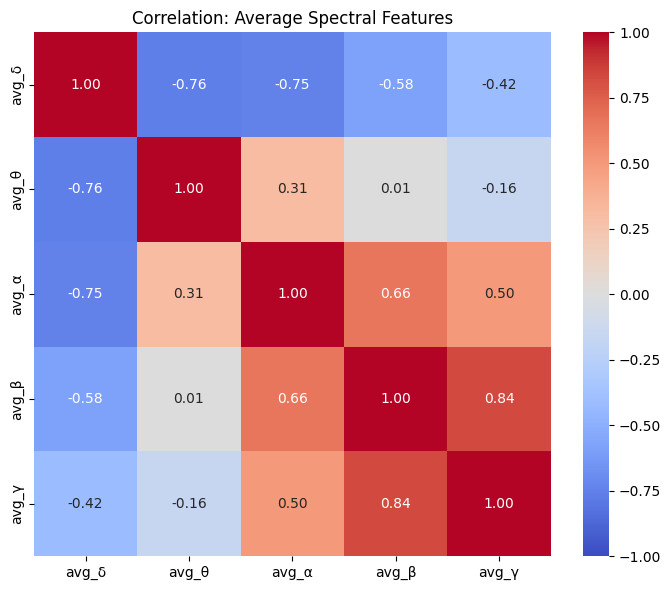

In [63]:
corr_avg = EEG_all[
    avg_band_features
].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_avg,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation: Average Spectral Features")
plt.tight_layout()
plt.show()

### Correlation among ratio features

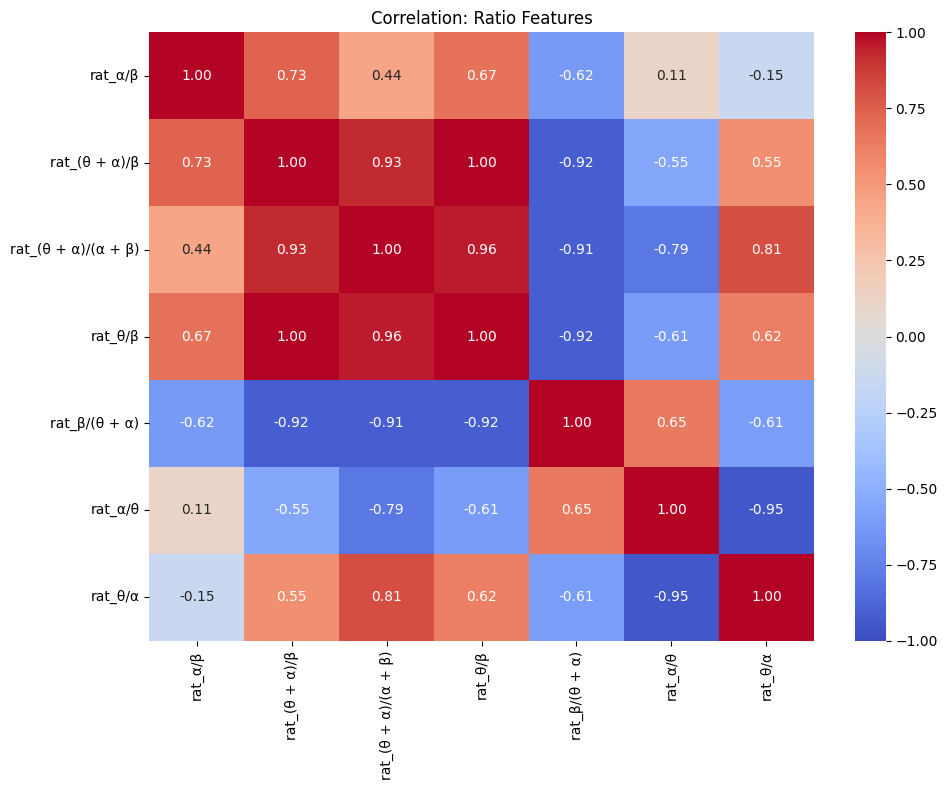

In [64]:
if len(ratio_features) > 1:

    corr_ratio = EEG_all[
        ratio_features
    ].corr()

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        corr_ratio,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1
    )

    plt.title("Correlation: Ratio Features")
    plt.tight_layout()
    plt.show()

### Correlation among wavelet features

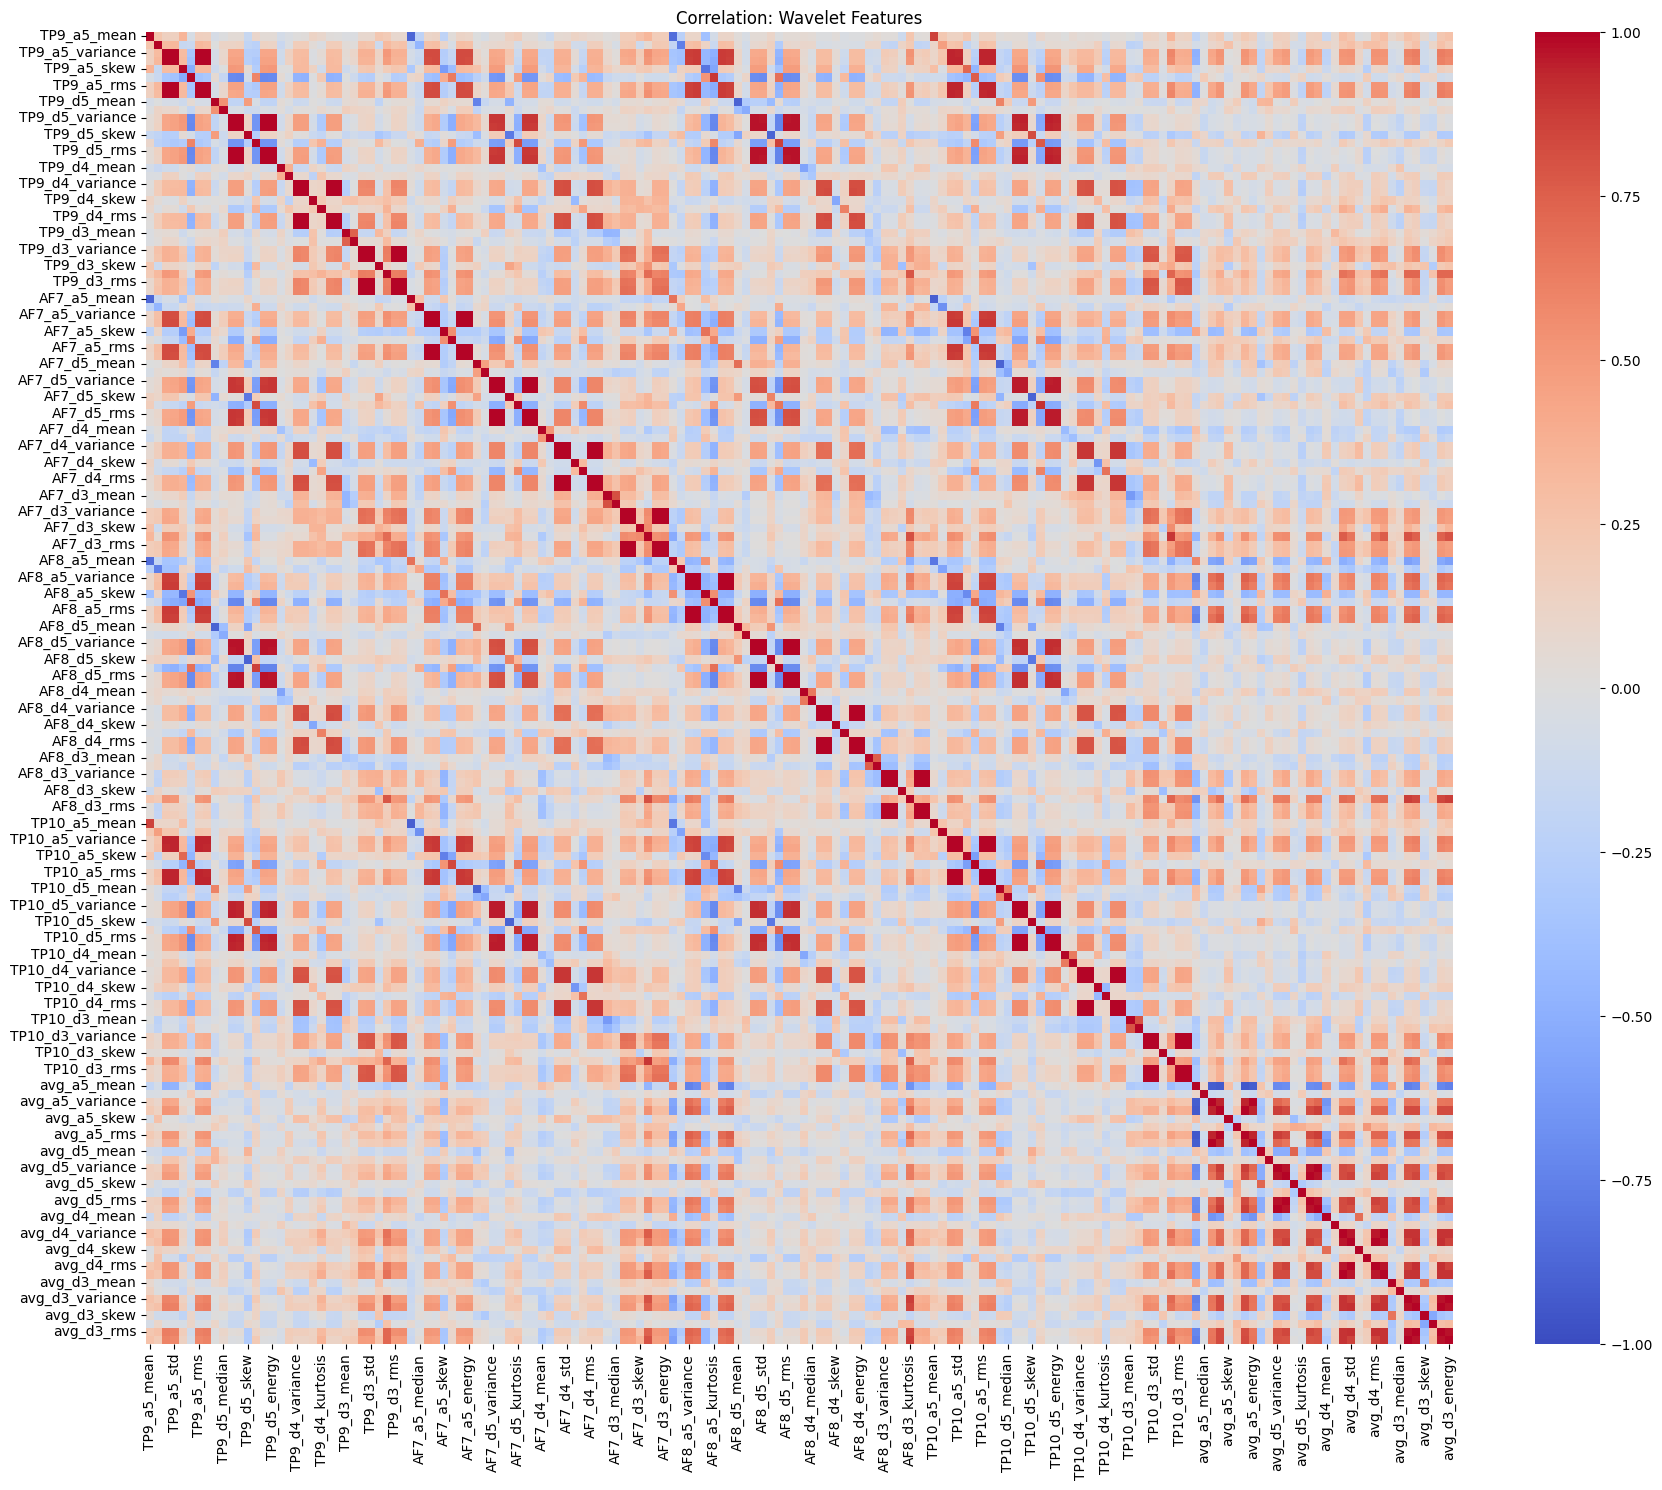

In [65]:
corr_wavelet = EEG_all[
    wavelet_features
].corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr_wavelet,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation: Wavelet Features")
plt.tight_layout()
plt.show()

too many wavelet features

In [66]:
corr_matrix = numeric_features.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "absolute_correlation"
]

high_corr_pairs = high_corr_pairs.sort_values(
    "absolute_correlation",
    ascending=False
)

high_corr_pairs.head(50)

,feature_1,feature_2,absolute_correlation
18520,avg_d3_std,avg_d3_rms,1.000000
18517,avg_d3_variance,avg_d3_energy,1.000000
18301,avg_d5_variance,avg_d5_energy,0.999999
18097,avg_a5_variance,avg_a5_energy,0.999998
18320,avg_d5_std,avg_d5_rms,0.999998
18452,avg_d4_std,avg_d4_rms,0.999998
18124,avg_a5_std,avg_a5_rms,0.999997
18441,avg_d4_variance,avg_d4_energy,0.999996
12537,AF7_d4_variance,AF7_d4_energy,0.999995
12644,AF7_d4_std,AF7_d4_rms,0.999995


In [67]:
high_corr_90 = high_corr_pairs[
    high_corr_pairs["absolute_correlation"] >= 0.90
]

print(
    f"Number of feature pairs with |r| >= 0.90: "
    f"{len(high_corr_90)}"
)

high_corr_90.head(50)

Number of feature pairs with |r| >= 0.90: 235


,feature_1,feature_2,absolute_correlation
18520,avg_d3_std,avg_d3_rms,1.000000
18517,avg_d3_variance,avg_d3_energy,1.000000
18301,avg_d5_variance,avg_d5_energy,0.999999
18097,avg_a5_variance,avg_a5_energy,0.999998
18320,avg_d5_std,avg_d5_rms,0.999998
18452,avg_d4_std,avg_d4_rms,0.999998
18124,avg_a5_std,avg_a5_rms,0.999997
18441,avg_d4_variance,avg_d4_energy,0.999996
12537,AF7_d4_variance,AF7_d4_energy,0.999995
12644,AF7_d4_std,AF7_d4_rms,0.999995


In [68]:
high_corr_95 = high_corr_pairs[
    high_corr_pairs["absolute_correlation"] >= 0.95
]

print(
    f"Number of feature pairs with |r| >= 0.95: "
    f"{len(high_corr_95)}"
)

Number of feature pairs with |r| >= 0.95: 152


In [69]:
def feature_family(feature):

    if feature in band_features:
        return "band"

    elif feature in avg_band_features:
        return "average_band"

    elif feature in ratio_features:
        return "ratio"

    elif feature in asymmetry_features:
        return "asymmetry"

    elif feature in wavelet_features:
        return "wavelet"

    else:
        return "other"

In [70]:
high_corr_90 = high_corr_90.copy()

high_corr_90["family_1"] = (
    high_corr_90["feature_1"]
    .apply(feature_family)
)

high_corr_90["family_2"] = (
    high_corr_90["feature_2"]
    .apply(feature_family)
)

high_corr_90.head(30)

,feature_1,feature_2,absolute_correlation,family_1,family_2
18520,avg_d3_std,avg_d3_rms,1.000000,wavelet,wavelet
18517,avg_d3_variance,avg_d3_energy,1.000000,wavelet,wavelet
18301,avg_d5_variance,avg_d5_energy,0.999999,wavelet,wavelet
18097,avg_a5_variance,avg_a5_energy,0.999998,wavelet,wavelet
18320,avg_d5_std,avg_d5_rms,0.999998,wavelet,wavelet
18452,avg_d4_std,avg_d4_rms,0.999998,wavelet,wavelet
18124,avg_a5_std,avg_a5_rms,0.999997,wavelet,wavelet
18441,avg_d4_variance,avg_d4_energy,0.999996,wavelet,wavelet
12537,AF7_d4_variance,AF7_d4_energy,0.999995,wavelet,wavelet
12644,AF7_d4_std,AF7_d4_rms,0.999995,wavelet,wavelet


i think that is because there's so many wavelet features

In [71]:
wavelet_stat_names = [
    "mean",
    "median",
    "variance",
    "std",
    "skew",
    "kurtosis",
    "rms",
    "energy"
]

In [72]:
for stat in wavelet_stat_names:

    matching = [
        c for c in wavelet_features
        if stat in c.lower()
    ]

    print(f"{stat}: {len(matching)} features")

mean: 20 features
median: 20 features
variance: 20 features
std: 20 features
skew: 20 features
kurtosis: 20 features
rms: 20 features
energy: 20 features


In [73]:
wavelet_stat_features = [
    c for c in wavelet_features
    if any(stat in c.lower() for stat in wavelet_stat_names)
]

corr_wavelet_stats = EEG_all[
    wavelet_stat_features
].corr()

In [75]:
#for every feature how many other features are correlated with it above 0.90

correlation_threshold = 0.90

redundancy_count = (
    corr_matrix >= correlation_threshold
).sum(axis=1) - 1

redundancy_table = pd.DataFrame({
    "feature": redundancy_count.index,
    "high_corr_count": redundancy_count.values
})

redundancy_table = redundancy_table.sort_values(
    "high_corr_count",
    ascending=False
)

redundancy_table.head(30)

,feature,high_corr_count
144,TP10_d5_energy,15
140,TP10_d5_std,15
139,TP10_d5_variance,15
143,TP10_d5_rms,15
108,AF8_d5_std,11
43,TP9_d5_variance,11
44,TP9_d5_std,11
47,TP9_d5_rms,11
112,AF8_d5_energy,11
111,AF8_d5_rms,11


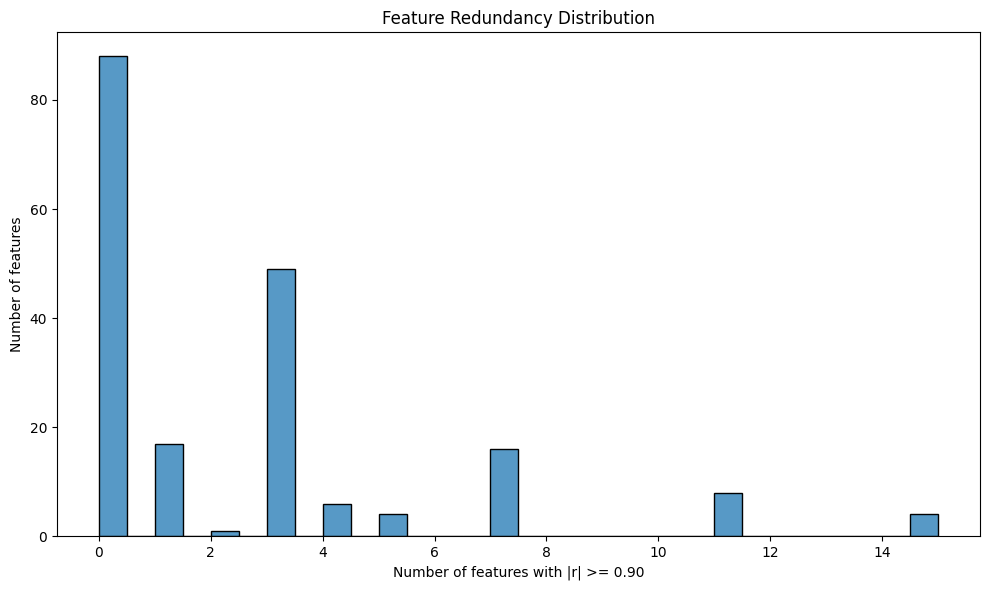

In [76]:
plt.figure(figsize=(10, 6))

sns.histplot(
    redundancy_table["high_corr_count"],
    bins=30
)

plt.xlabel("Number of features with |r| >= 0.90")
plt.ylabel("Number of features")
plt.title("Feature Redundancy Distribution")

plt.tight_layout()
plt.show()

In [79]:
feature_analysis = stats_results.copy()

feature_analysis["family"] = (
    feature_analysis["feature"]
    .apply(feature_family)
)

feature_analysis = feature_analysis[
    [
        "feature",
        "family",
        "H_statistic",
        "p_value",
        "p_fdr",
        "epsilon_squared",
        "significant"
    ]
]

feature_analysis = feature_analysis.sort_values(
    ["significant", "epsilon_squared"],
    ascending=[False, False]
)

feature_analysis.head(30)

,feature,family,H_statistic,p_value,p_fdr,epsilon_squared,significant
0,AF8_d3_variance,wavelet,98.403826,4.284308e-22,2.293532e-20,0.338259,True
1,AF8_d3_std,wavelet,98.403826,4.284308e-22,2.293532e-20,0.338259,True
2,AF8_d3_rms,wavelet,98.196009,4.753434e-22,2.293532e-20,0.337530,True
3,AF8_d3_energy,wavelet,98.196009,4.753434e-22,2.293532e-20,0.337530,True
4,γ_AF8,band,73.074512,1.355412e-16,5.231891e-15,0.249384,True
5,β_AF8,band,70.176564,5.772352e-16,1.856773e-14,0.239216,True
6,AF7_d3_energy,wavelet,62.186647,3.135748e-14,7.564993e-13,0.211181,True
7,AF7_d3_rms,wavelet,62.186647,3.135748e-14,7.564993e-13,0.211181,True
9,AF7_d3_variance,wavelet,61.695613,4.008371e-14,7.736156e-13,0.209458,True
8,AF7_d3_std,wavelet,61.695613,4.008371e-14,7.736156e-13,0.209458,True


I have to combine ​​statistical relevance, effect size, redundance, predictive importance and cross validation to determine final feature set